# Sensor2EventLog Toy Walkthrough

This notebook creates a tiny synthetic sensor dataset, extracts rule-based features, and turns the labeled state sequence into an interval event log.

The setup cell below locates the repository root automatically and adds it to `sys.path`, which makes the notebook more reliable when opened from different working directories.

In [1]:
import sys
from pathlib import Path
import types

import pandas as pd

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "features").exists():
            return candidate
    raise RuntimeError("Could not locate the Sensor2EventLog repository root.")

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import config as base_config
from core.pipeline import Sensor2EventLogPipeline
from tutorial.toy_walkthrough import (
    OUTPUT_DIR,
    compute_dfg,
    build_feature_plan,
    make_toy_dataset,
    plot_process_graph,
    plot_time_series,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using repository root: {repo_root}")
print(f"Writing tutorial artifacts to: {OUTPUT_DIR}")


Using repository root: /home/barbon/Python/Sensor2EventLog
Writing tutorial artifacts to: /home/barbon/Python/Sensor2EventLog/tutorial/output


In [2]:
df = make_toy_dataset()
feature_plan = build_feature_plan()

dataset_path = OUTPUT_DIR / "toy_sensor_data.csv"
df.to_csv(dataset_path, index=False)

cfg = types.SimpleNamespace(**{k: v for k, v in base_config.__dict__.items() if k.isupper()})
cfg.PATHS = {
    "event_log": str(OUTPUT_DIR / "toy_event_log.csv"),
    "filtered_log": str(OUTPUT_DIR / "toy_event_log_filtered.csv"),
}

pipeline = Sensor2EventLogPipeline(cfg)
results = pipeline.run(
    data_path=str(dataset_path),
    feature_plan=feature_plan,
    mode="unsupervised",
    use_cip=False,
    n_unsup=None,
    random_seed=42,
    return_intermediate=True,
    min_duration_seconds=0.0,
)

features = results["features"]
diagnostics = results["diagnostics"]
event_log = results["event_log"].to_dataframe()
dfg = compute_dfg(event_log)

df.head(10)


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule


,batch_id,timestamp,state,T,Q_in,Q_out
0,batch_01,0,Idle,24.001,0.009,0.000
1,batch_01,60,Idle,23.599,0.000,0.000
2,batch_01,120,Idle,24.027,0.040,0.000
3,batch_01,180,Fill,23.721,0.765,0.031
4,batch_01,240,Fill,24.047,0.722,0.019
5,batch_01,300,Fill,24.313,0.710,0.006
6,batch_01,360,Fill,23.144,0.711,0.000
7,batch_01,420,Fill,23.894,0.712,0.028
8,batch_01,480,HeatUp,30.071,0.344,0.000
9,batch_01,540,HeatUp,40.258,0.349,0.003


In [3]:
event_columns = [col for col in features.columns if col.startswith("event_")]
features[event_columns].head(12)

,event_fill_rule,event_hold_rule,event_discharge_rule
0,0,0,0
1,0,0,0
2,0,0,0
3,1,0,0
4,1,0,0
5,1,0,0
6,1,0,0
7,1,0,0
8,0,0,0
9,0,0,0


In [4]:
event_log

,case_id,activity_sequence,activity,start_timestamp,end_timestamp,duration_seconds,event_count
0,batch_01,1,Idle,0,120,120,3
1,batch_01,2,Fill,180,420,240,5
2,batch_01,3,HeatUp,480,720,240,5
3,batch_01,4,Hold,780,960,180,4
4,batch_01,5,Cool,1020,1200,180,4
5,batch_01,6,Discharge,1260,1380,120,3
6,batch_02,1,Idle,0,120,120,3
7,batch_02,2,Fill,180,420,240,5
8,batch_02,3,HeatUp,480,720,240,5
9,batch_02,4,Hold,780,960,180,4


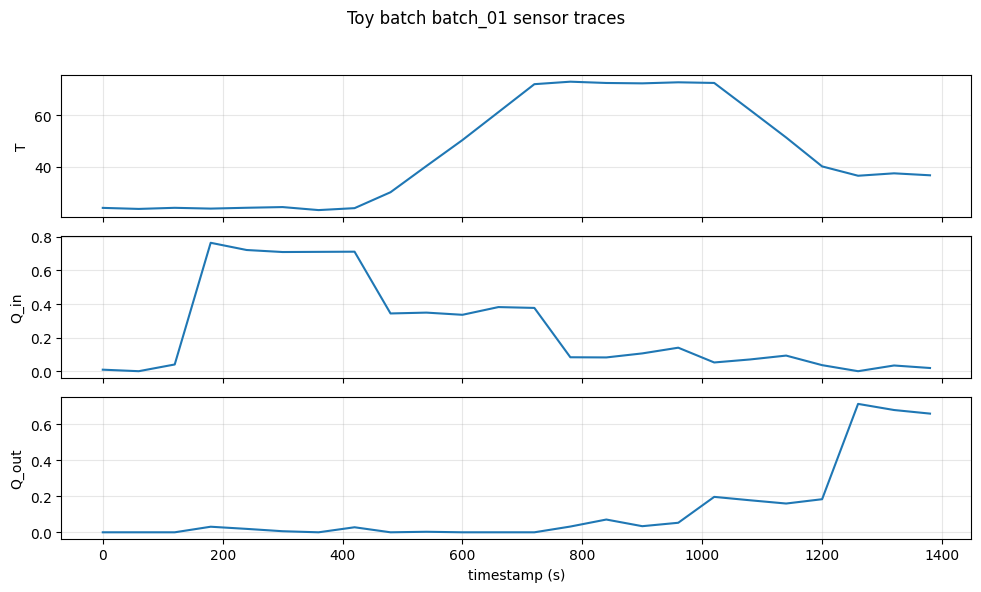

In [5]:
plot_time_series(df, batch_id="batch_01", feature_cols=["T", "Q_in", "Q_out"])

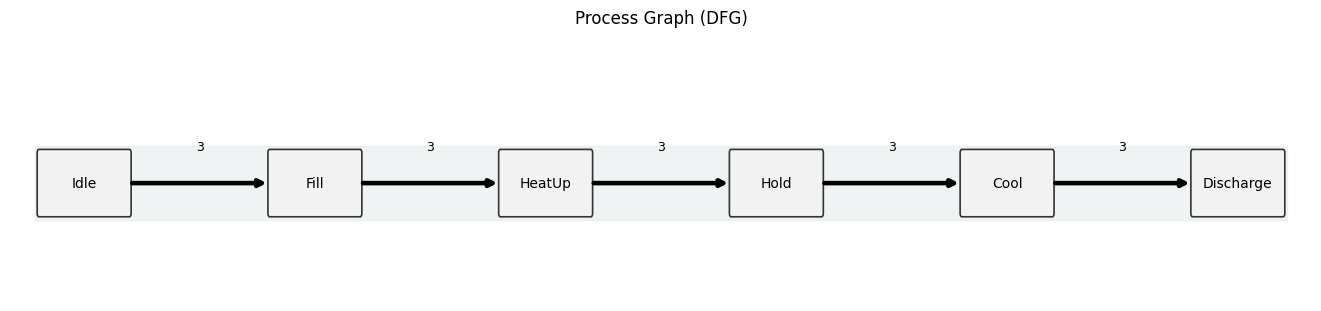

In [6]:
plot_process_graph(dfg, node_order=["Idle", "Fill", "HeatUp", "Hold", "Cool", "Discharge"])

In [7]:
pd.DataFrame(diagnostics["recommendations"]).head(10)

,type,state,explainability,frequency,action,priority,suggested_approaches,rule,coverage,precision,suggested_families
0,UNEXPLAINABLE_STATE,Idle,0.00,0.125000,State 'Idle' is largely unexplained (explainab...,CRITICAL,"[state_decomposition, feature_expansion, proba...",NaN,NaN,NaN,NaN
1,UNEXPLAINABLE_STATE,HeatUp,0.00,0.208333,State 'HeatUp' is largely unexplained (explain...,CRITICAL,"[state_decomposition, feature_expansion, proba...",NaN,NaN,NaN,NaN
2,UNEXPLAINABLE_STATE,Cool,0.25,0.166667,State 'Cool' is largely unexplained (explainab...,CRITICAL,"[state_decomposition, feature_expansion, proba...",NaN,NaN,NaN,NaN
3,INEFFECTIVE_RULE,Idle,NaN,NaN,Rule 'event_fill_rule' for state 'Idle' perfor...,HIGH,NaN,event_fill_rule,0.0,0.0,[all]
4,INEFFECTIVE_RULE,HeatUp,NaN,NaN,Rule 'event_fill_rule' for state 'HeatUp' perf...,HIGH,NaN,event_fill_rule,0.0,0.0,[all]
5,INEFFECTIVE_RULE,Hold,NaN,NaN,Rule 'event_fill_rule' for state 'Hold' perfor...,HIGH,NaN,event_fill_rule,0.0,0.0,[all]
6,INEFFECTIVE_RULE,Cool,NaN,NaN,Rule 'event_fill_rule' for state 'Cool' perfor...,HIGH,NaN,event_fill_rule,0.0,0.0,[all]
7,INEFFECTIVE_RULE,Discharge,NaN,NaN,Rule 'event_fill_rule' for state 'Discharge' p...,HIGH,NaN,event_fill_rule,0.0,0.0,[all]
8,INEFFECTIVE_RULE,Idle,NaN,NaN,Rule 'event_hold_rule' for state 'Idle' perfor...,HIGH,NaN,event_hold_rule,0.0,0.0,[all]
9,INEFFECTIVE_RULE,Fill,NaN,NaN,Rule 'event_hold_rule' for state 'Fill' perfor...,HIGH,NaN,event_hold_rule,0.0,0.0,[all]


In [8]:
df.to_csv(OUTPUT_DIR / "toy_sensor_data.csv", index=False)
features.to_csv(OUTPUT_DIR / "toy_features.csv", index=False)
event_log.to_csv(OUTPUT_DIR / "toy_event_log.csv", index=False)

print(f"Artifacts written to: {OUTPUT_DIR}")

Artifacts written to: /home/barbon/Python/Sensor2EventLog/tutorial/output


## Results Notes

- The raw signals line up with the story: `Q_in` spikes in **Fill**, `T` rises in **HeatUp**, and `Q_out` is highest in **Discharge**.
- The event rules fire where they should. `event_fill_rule` turns on in **Fill**, `event_hold_rule` in **Hold**, and `event_discharge_rule` in **Discharge**.
- The event log is a clean, linear chain for each batch (`Idle → Fill → HeatUp → Hold → Cool → Discharge`). That’s what we want in a toy example.
- The diagnostics show **UNEXPLAINABLE_STATE** for `Idle`, `HeatUp`, and `Cool` because we intentionally defined only three rules. In a real use case, you’d add rules or features for those states.
- If you expand the rule set, you should see those explainability warnings shrink and the recommendations move toward fine-tuning thresholds instead of redesigning rules.
